In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import warnings
warnings.filterwarnings("ignore")
import scipy.cluster.hierarchy as sch

sns.set_theme(style="darkgrid")
plt.style.use("seaborn")

In [25]:
team= 'GSW'

In [26]:
df_team= pd.read_csv(f'../Data/{team}.csv')
df_team["Date"] = pd.to_datetime(df_team["Date"]) 
df_team.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,Tm_FG,Tm_FGA,Tm_FG%,...,Tm_BLK%,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pace,Opp_Pace
53,GSW,DAL,2025-02-12,L,A,107,111,41,96,0.427,...,11.8,13.3,47.6,9.3,11.5,13.8,2.0,2.0,97.269125,97.269125
54,GSW,HOU,2025-02-13,W,A,105,98,35,89,0.393,...,10.5,9.8,63.2,7.0,10.4,16.5,1.0,1.0,100.627535,100.627535
55,GSW,SAC,2025-02-21,W,A,132,108,50,93,0.538,...,6.4,10.9,65.0,8.3,6.0,21.6,8.0,8.0,96.960980,96.960980
56,GSW,DAL,2025-02-23,W,H,126,102,47,98,0.480,...,12.0,8.5,63.2,7.0,6.9,16.6,2.0,2.0,99.571235,99.571235
57,GSW,CHO,2025-02-25,W,H,128,92,49,100,0.490,...,10.2,10.0,54.5,6.9,13.8,20.5,2.0,1.0,100.927695,100.927695


In [27]:
df_opp= pd.read_csv(f'../Data/vs {team}.csv')
df_opp["Date"] = pd.to_datetime(df_opp["Date"]) 
df_opp.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,Tm_FG,Tm_FGA,Tm_FG%,...,Tm_BLK%,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pace,Opp_Pace
53,DAL,GSW,2025-02-12,W,H,111,107,42,87,0.483,...,11.5,13.8,70.7,9.3,11.8,13.3,2.0,2.0,97.269125,97.269125
54,HOU,GSW,2025-02-13,L,H,98,105,38,93,0.409,...,10.4,16.5,74.3,12.9,10.5,9.8,1.0,1.0,100.627535,100.627535
55,SAC,GSW,2025-02-21,L,H,108,132,40,79,0.506,...,6.0,21.6,80.0,13.4,6.4,10.9,8.0,8.0,96.960980,96.960980
56,DAL,GSW,2025-02-23,L,A,102,126,38,82,0.463,...,6.9,16.6,63.8,10.0,12.0,8.5,2.0,2.0,99.571235,99.571235
57,CHO,GSW,2025-02-25,L,A,92,128,33,89,0.371,...,13.8,20.5,81.6,15.9,10.2,10.0,1.0,2.0,100.927695,100.927695


In [28]:
X= df_team[df_team.columns[3:]]
X

,Result,H/A,Tm_PTS,Opp_PTS,Tm_FG,Tm_FGA,Tm_FG%,Tm_2P,Tm_2PA,Tm_2P%,...,Tm_BLK%,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pace,Opp_Pace
0,W,A,140,104,48,93,0.516,28,45,0.622,...,8.6,14.5,58.3,9.3,8.9,14.6,5.0,5.0,107.219865,107.219865
1,W,A,127,86,51,106,0.481,31,56,0.554,...,12.0,12.1,62.1,7.7,8.9,17.5,2.0,2.0,104.123725,104.123725
2,L,H,104,112,38,88,0.432,24,45,0.533,...,8.6,17.7,64.3,10.8,4.4,15.2,2.0,1.0,102.036360,102.036360
3,W,H,124,106,46,97,0.474,25,51,0.490,...,17.3,7.2,57.5,4.1,11.8,22.1,2.0,2.0,97.267495,97.267495
4,W,H,104,89,41,87,0.471,28,49,0.571,...,16.7,13.1,72.7,7.7,12.2,13.2,1.0,1.0,90.660465,90.660465
5,W,A,127,121,40,78,0.513,25,46,0.543,...,6.5,12.3,61.4,9.6,13.0,8.6,3.0,2.0,94.556780,94.556780
6,W,A,125,112,44,97,0.454,32,60,0.533,...,13.2,5.9,69.0,3.9,13.3,8.7,2.0,2.0,102.924065,102.924065
7,W,A,118,112,42,91,0.462,28,57,0.491,...,13.9,9.8,57.9,5.2,5.3,10.8,2.0,2.0,95.884110,95.884110
8,L,A,117,136,47,98,0.480,34,56,0.607,...,9.3,14.0,71.7,6.6,12.5,17.0,2.0,2.0,106.797455,106.797455
9,W,A,127,116,45,89,0.506,24,46,0.522,...,4.9,13.1,59.5,4.1,13.0,9.4,2.0,2.0,98.359140,98.359140


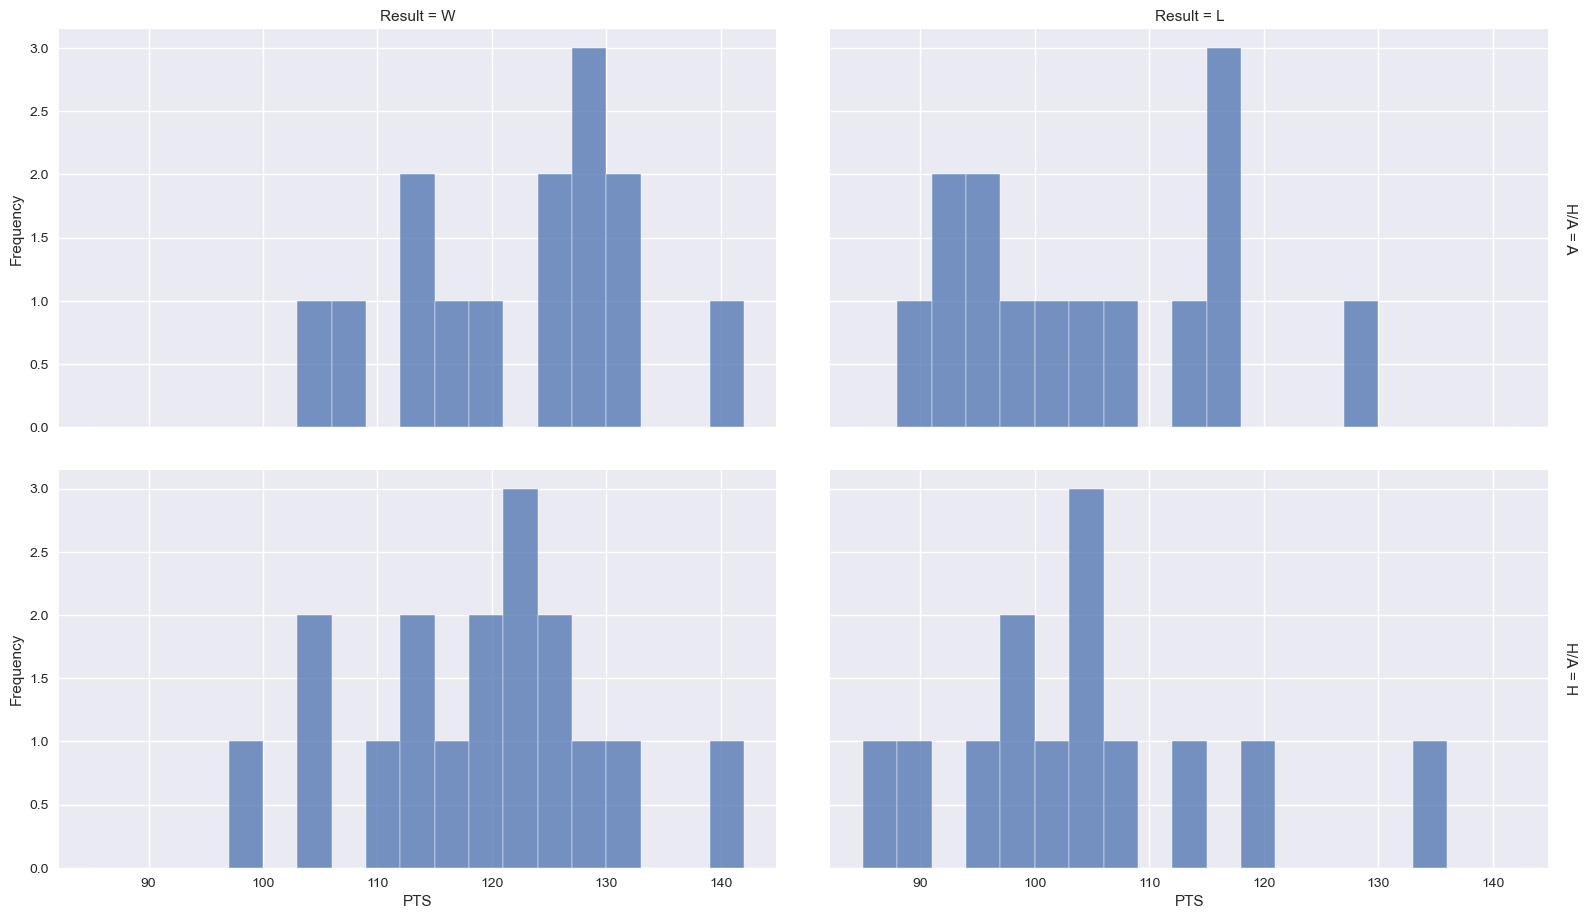

In [29]:
g = sns.displot(
    X, x="Tm_PTS", col="Result", row="H/A",
    binwidth=3, height=3, facet_kws=dict(margin_titles=True))

g.fig.set_size_inches(18, 10)
g.set_axis_labels("PTS", "Frequency")

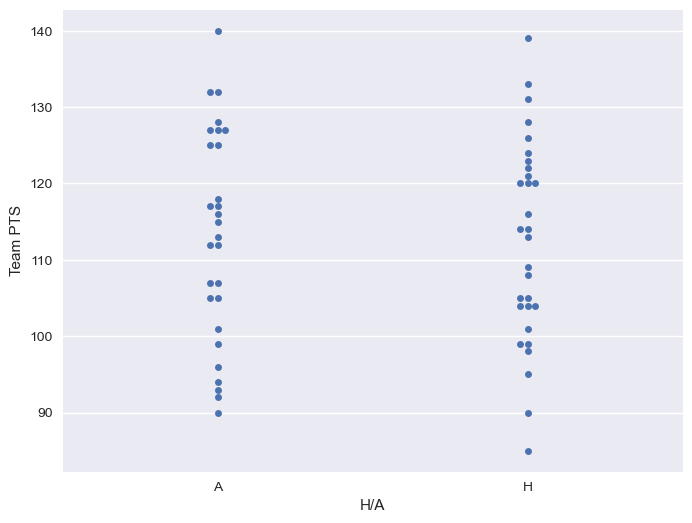

In [30]:
plt.figure(figsize=(8, 6))
#sns.set_style('whitegrid')
sns.swarmplot(x='H/A', y='Tm_PTS', data=X)
plt.xlabel("H/A")
plt.ylabel("Team PTS")
#plt.title("Total bill per size of the table")
plt.show()

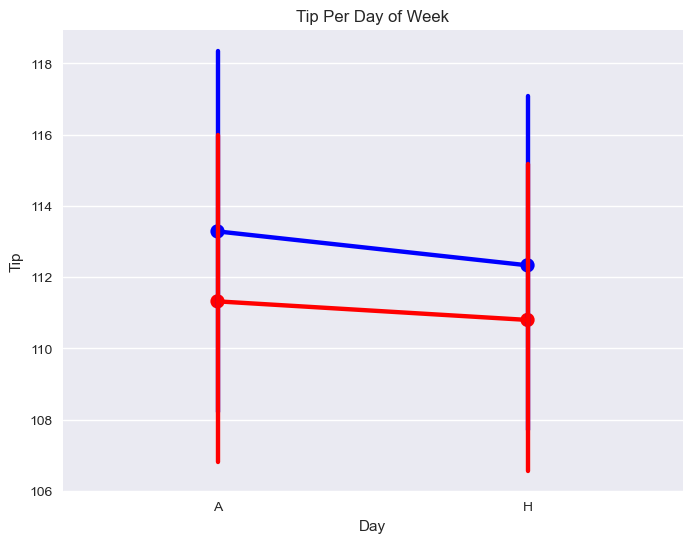

In [31]:
plt.figure(figsize=(8, 6))
sns.pointplot(x="H/A", y="Tm_PTS", data=X, color='#0000ff')
sns.pointplot(x="H/A", y="Opp_PTS", data=X, color='#ff0000')
plt.xlabel("Day")
plt.ylabel("Tip")
plt.title("Tip Per Day of Week")
plt.show()

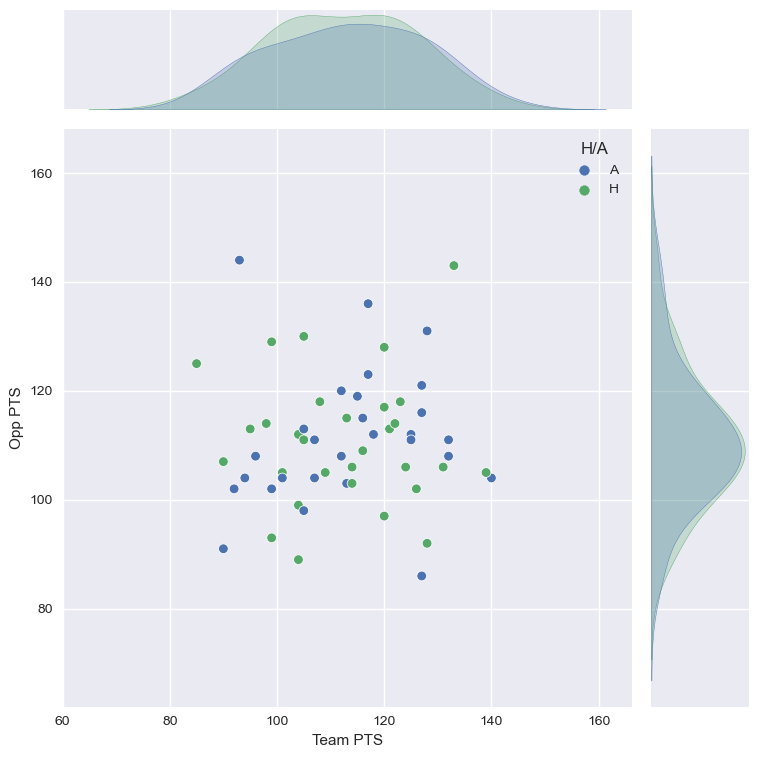

In [32]:
g = sns.jointplot(x='Tm_PTS', y='Opp_PTS', hue='H/A', data=X)
g.fig.set_size_inches(8, 8)
g.set_axis_labels("Team PTS", "Opp PTS")
plt.show()

Text(0, 0.5, 'PTS')

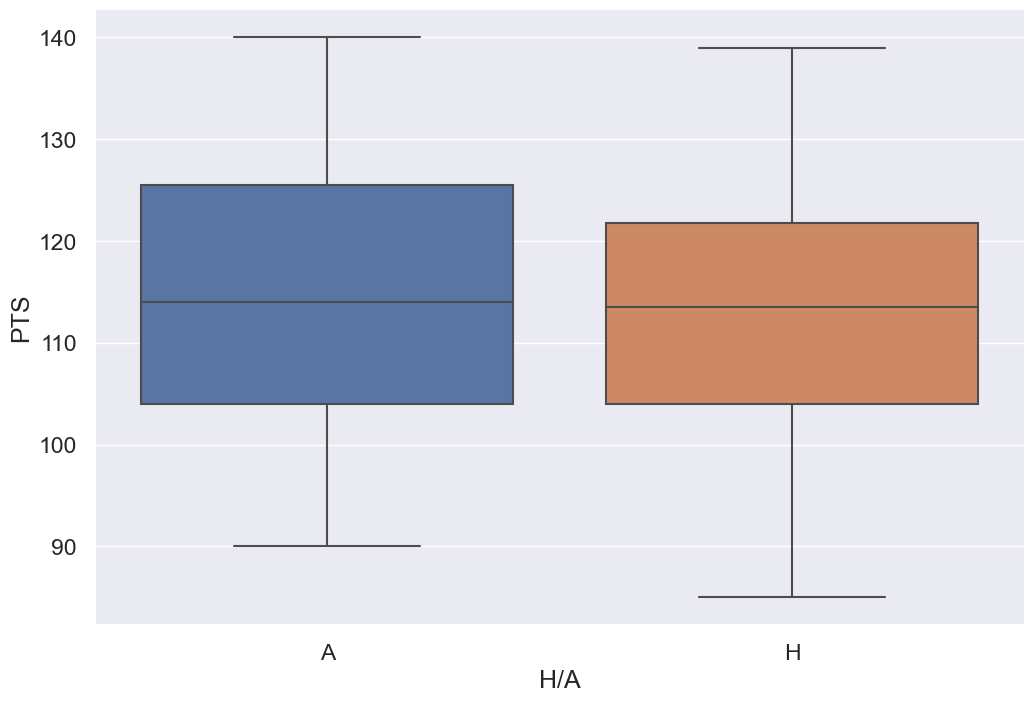

In [33]:
sns.set(font_scale = 1.5)
sns.boxplot(x='H/A', y='Tm_PTS', data=X)
plt.gcf().set_size_inches(12, 8)
plt.xlabel("H/A")
plt.ylabel("PTS")

Text(0, 0.5, 'Opp_PTS')

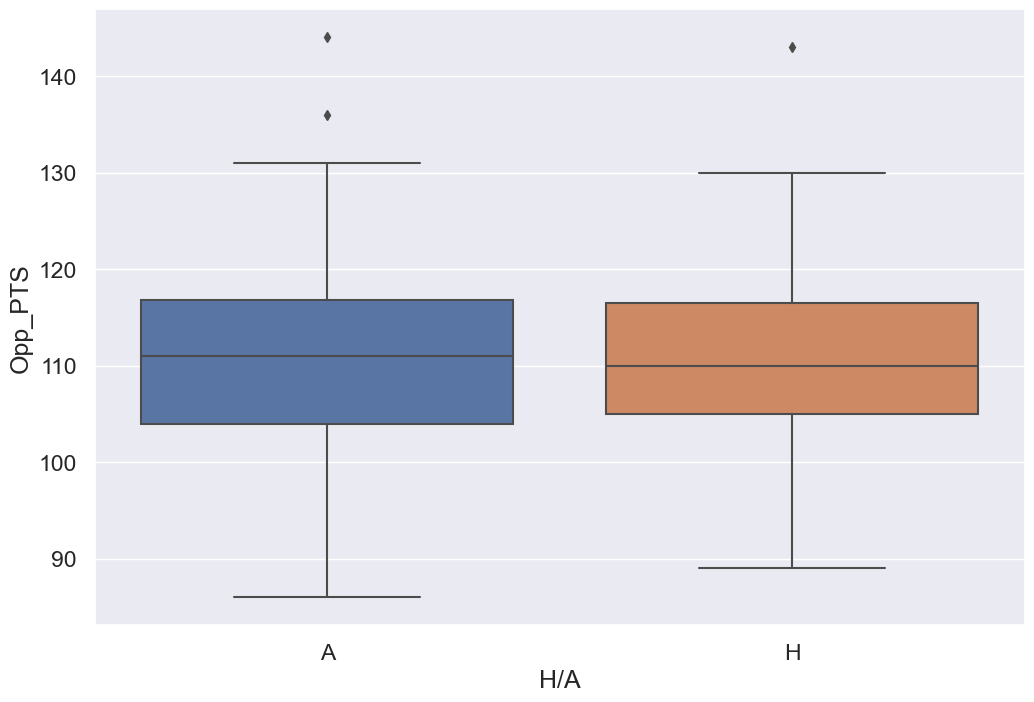

In [34]:
sns.set(font_scale = 1.5)
sns.boxplot(x='H/A', y='Opp_PTS', data=X)
plt.gcf().set_size_inches(12, 8)
plt.xlabel("H/A")
plt.ylabel("Opp_PTS")

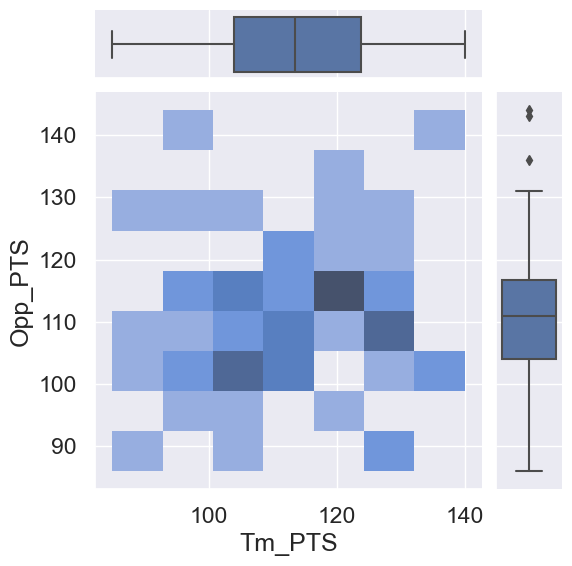

In [35]:
g = sns.JointGrid(data=X, x="Tm_PTS", y="Opp_PTS")
g.plot_joint(sns.histplot)
g.plot_marginals(sns.boxplot)

In [36]:
shooting= ['Tm_PTS', 'Tm_FGA', 'Tm_FG%', 'Tm_2PA', 'Tm_2P%', 'Tm_3PA', 'Tm_3P%', 'Tm_FTA', 'Tm_FT%', 'Result']
# 'Tm_ORB', 'Tm_AST', 'Tm_TOV',
#          'Tm_ORtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_ORB%','Tm_AST%', 'Opp_DRB', 'Opp_STL', 'Opp_BLK', 
 #         'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 'Tm_Pace', 'Result']

In [37]:
X_sh= df_team[shooting]

In [38]:
defence= ['Tm_DRB', 'Tm_STL', 'Tm_BLK', 'Tm_DRtg', 'Tm_DRB%', 'Tm_STL%', 'Tm_BLK%', 'Tm_TOV%', 'Opp_PTS', 'Opp_FGA', 'Opp_FG%', 
          'Opp_2PA', 'Opp_2P%', 'Opp_3PA', 'Opp_3P%', 'Opp_FTA', 'Opp_FT%', 'Opp_ORB', 'Opp_AST', 'Opp_TOV', 'Opp_ORtg', 'Opp_FTr', 
          'Opp_3PAr', 'Opp_TS%', 'Opp_eFG%', 'Opp_FT/FGA', 'Opp_ORB%','Opp_AST%', 'Opp_Pace', 'Result']

In [39]:
X_def= df_team[defence]

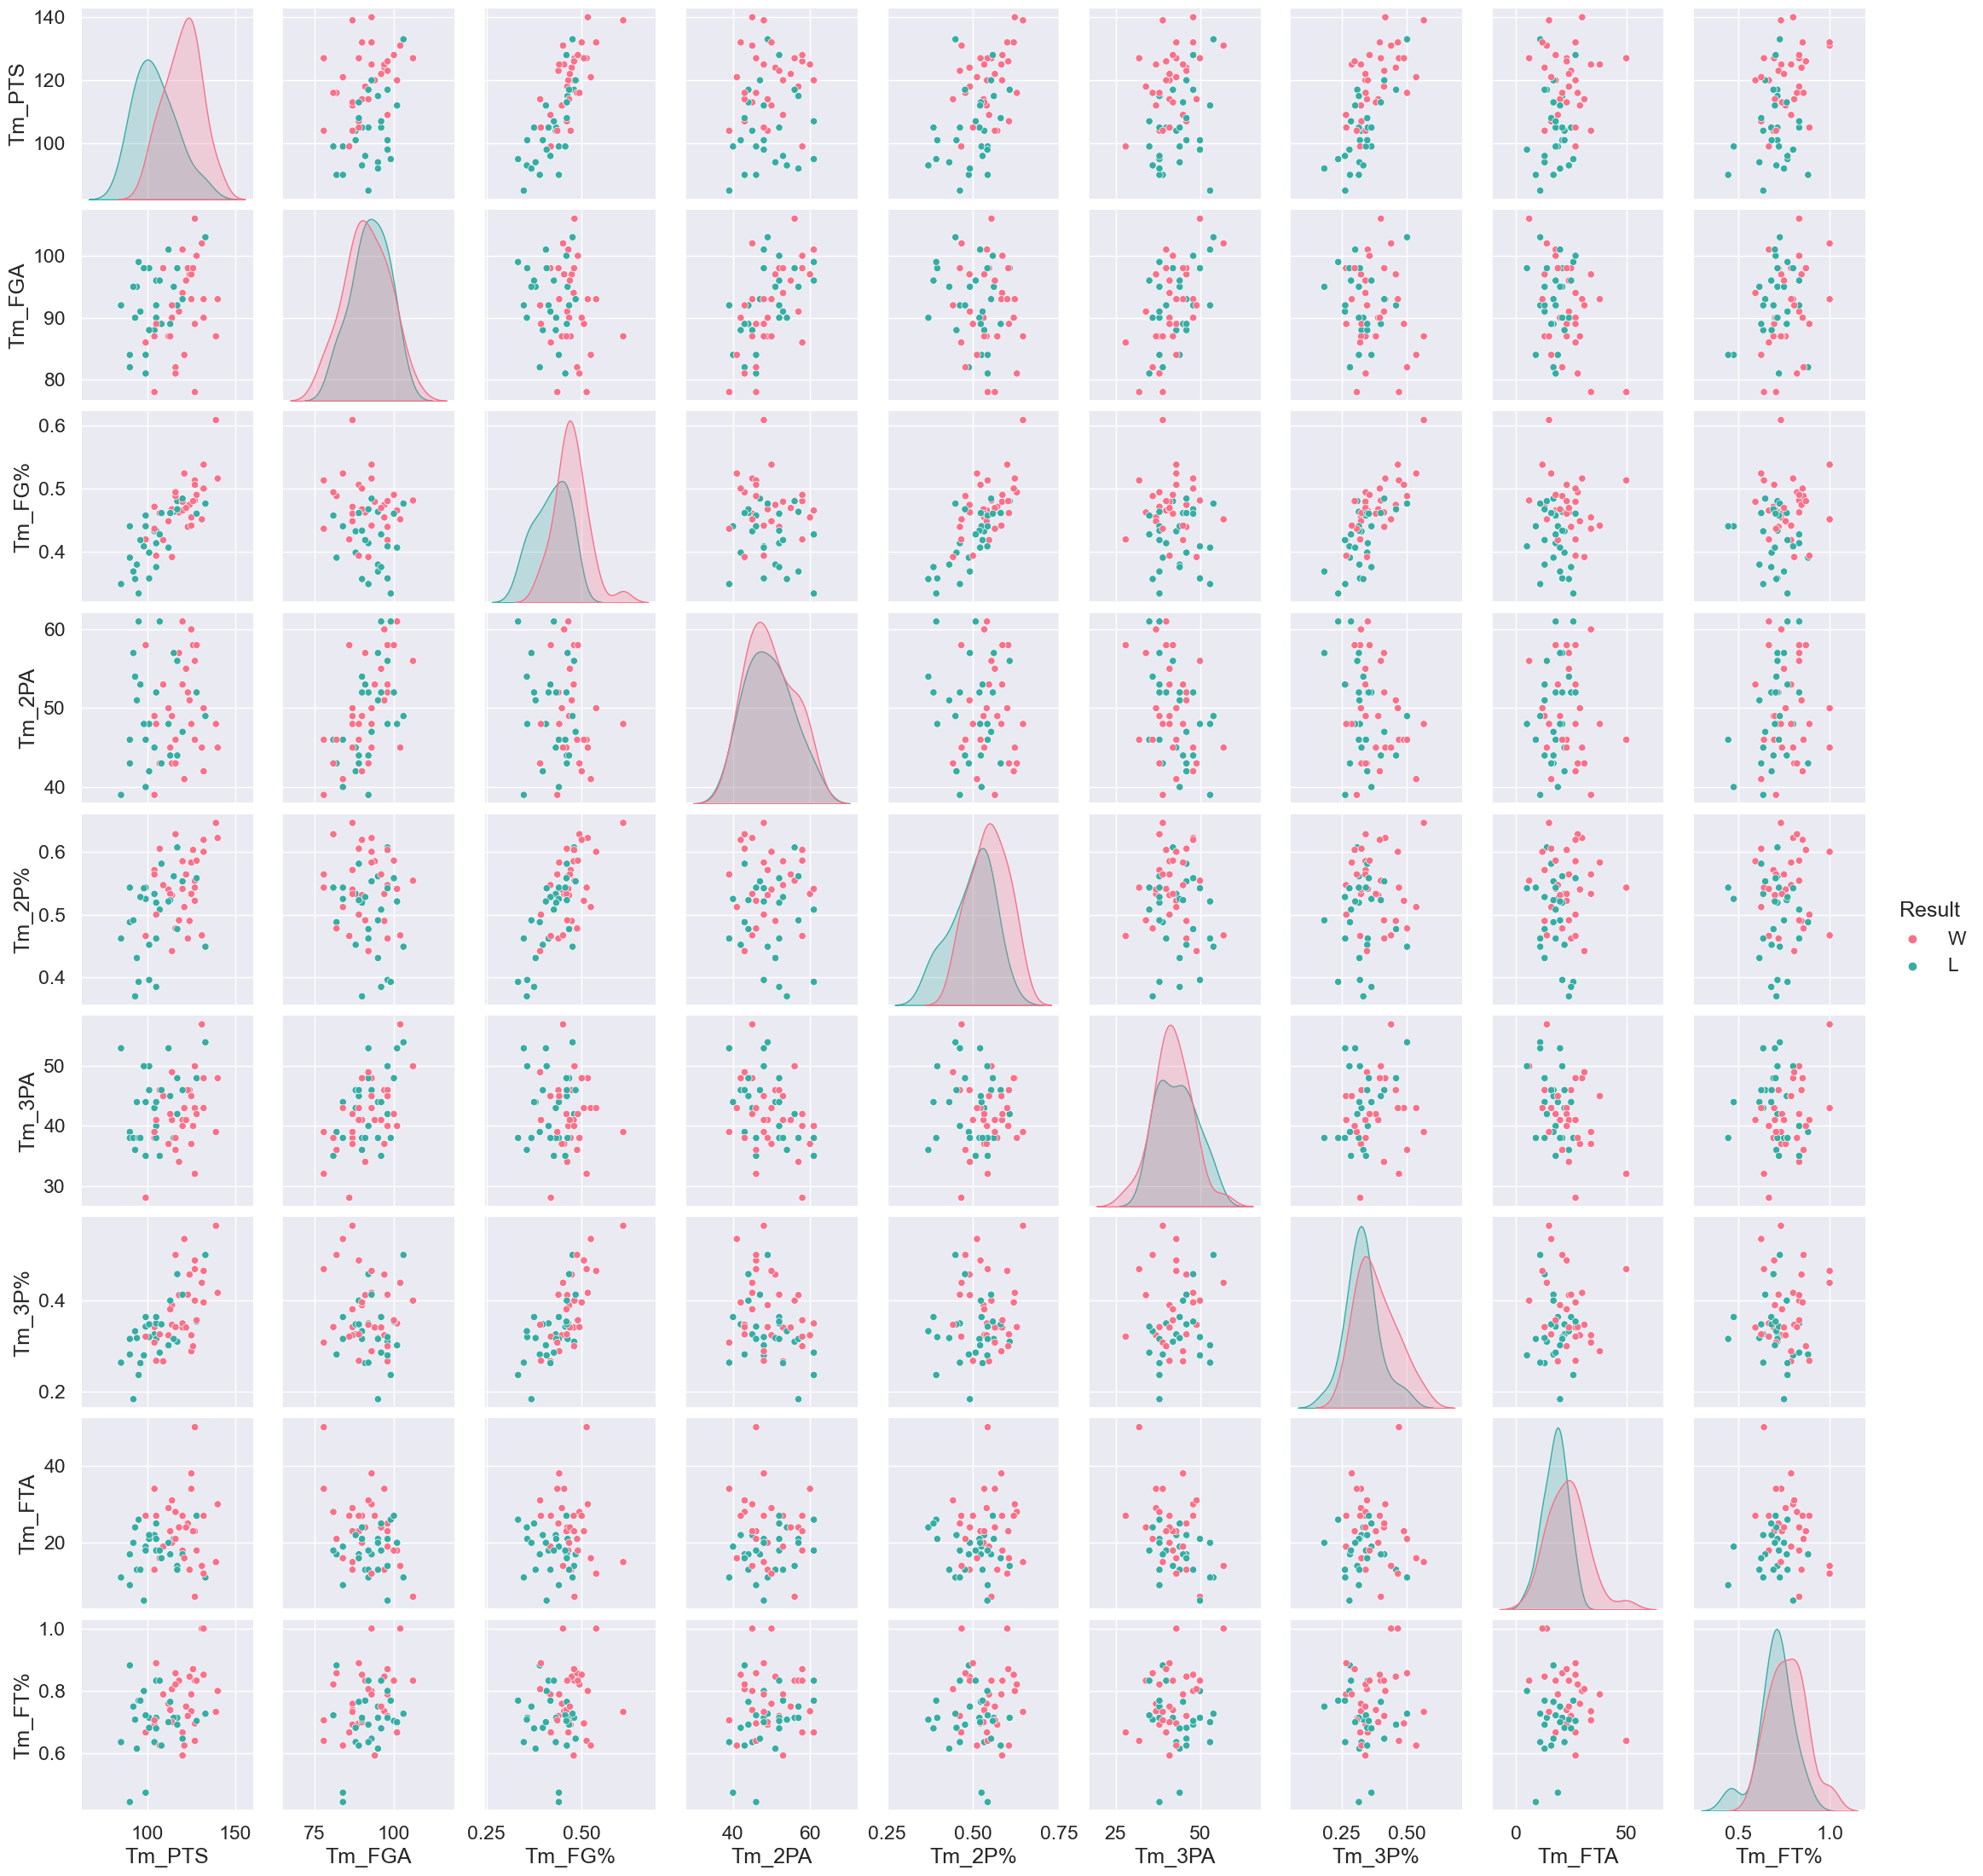

In [40]:
sns.pairplot(X_sh, hue="Result", diag_kind='kde', kind='scatter', palette='husl')
plt.show()

In [41]:
basic= ['Tm_PTS', 'Result', 'Tm_ORB', 'Tm_AST', 'Tm_TOV', 'Opp_STL', 'Opp_BLK']
#          'Tm_ORtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_ORB%','Tm_AST%', 'Opp_DRB',  
 #         'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 'Tm_Pace', 'Result']

In [42]:
X_bas= df_team[basic]


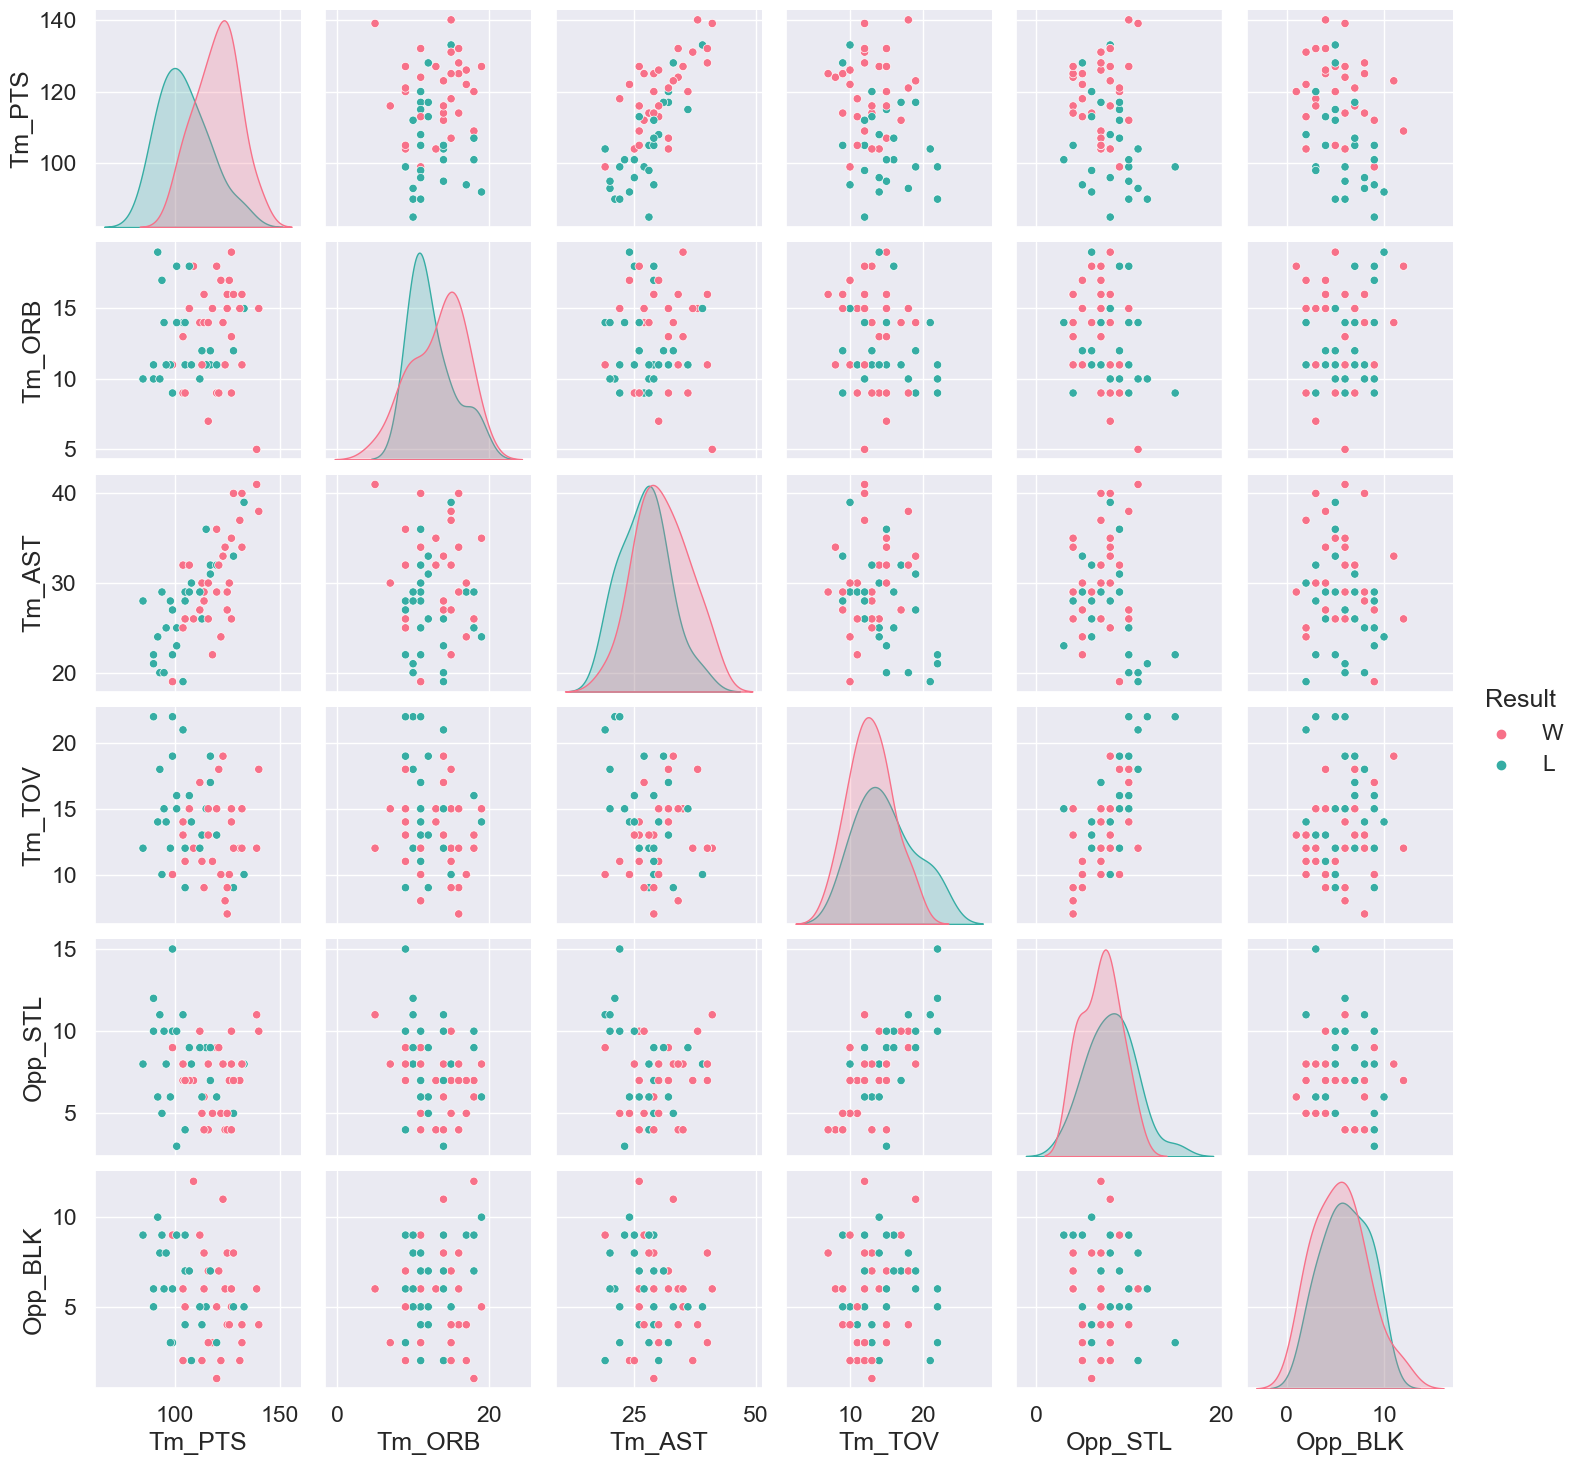

In [51]:
sns.pairplot(X_bas, hue="Result", diag_kind='kde', kind='scatter', palette='husl')
plt.show()

In [44]:
adv_sh= ['Tm_PTS', 'Result', 'Tm_ORtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_Pace']#, 'Tm_ORB%','Tm_AST%', 'Opp_DRB',           
#         'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 


In [47]:
X_adv_sh= df_team[adv_sh]


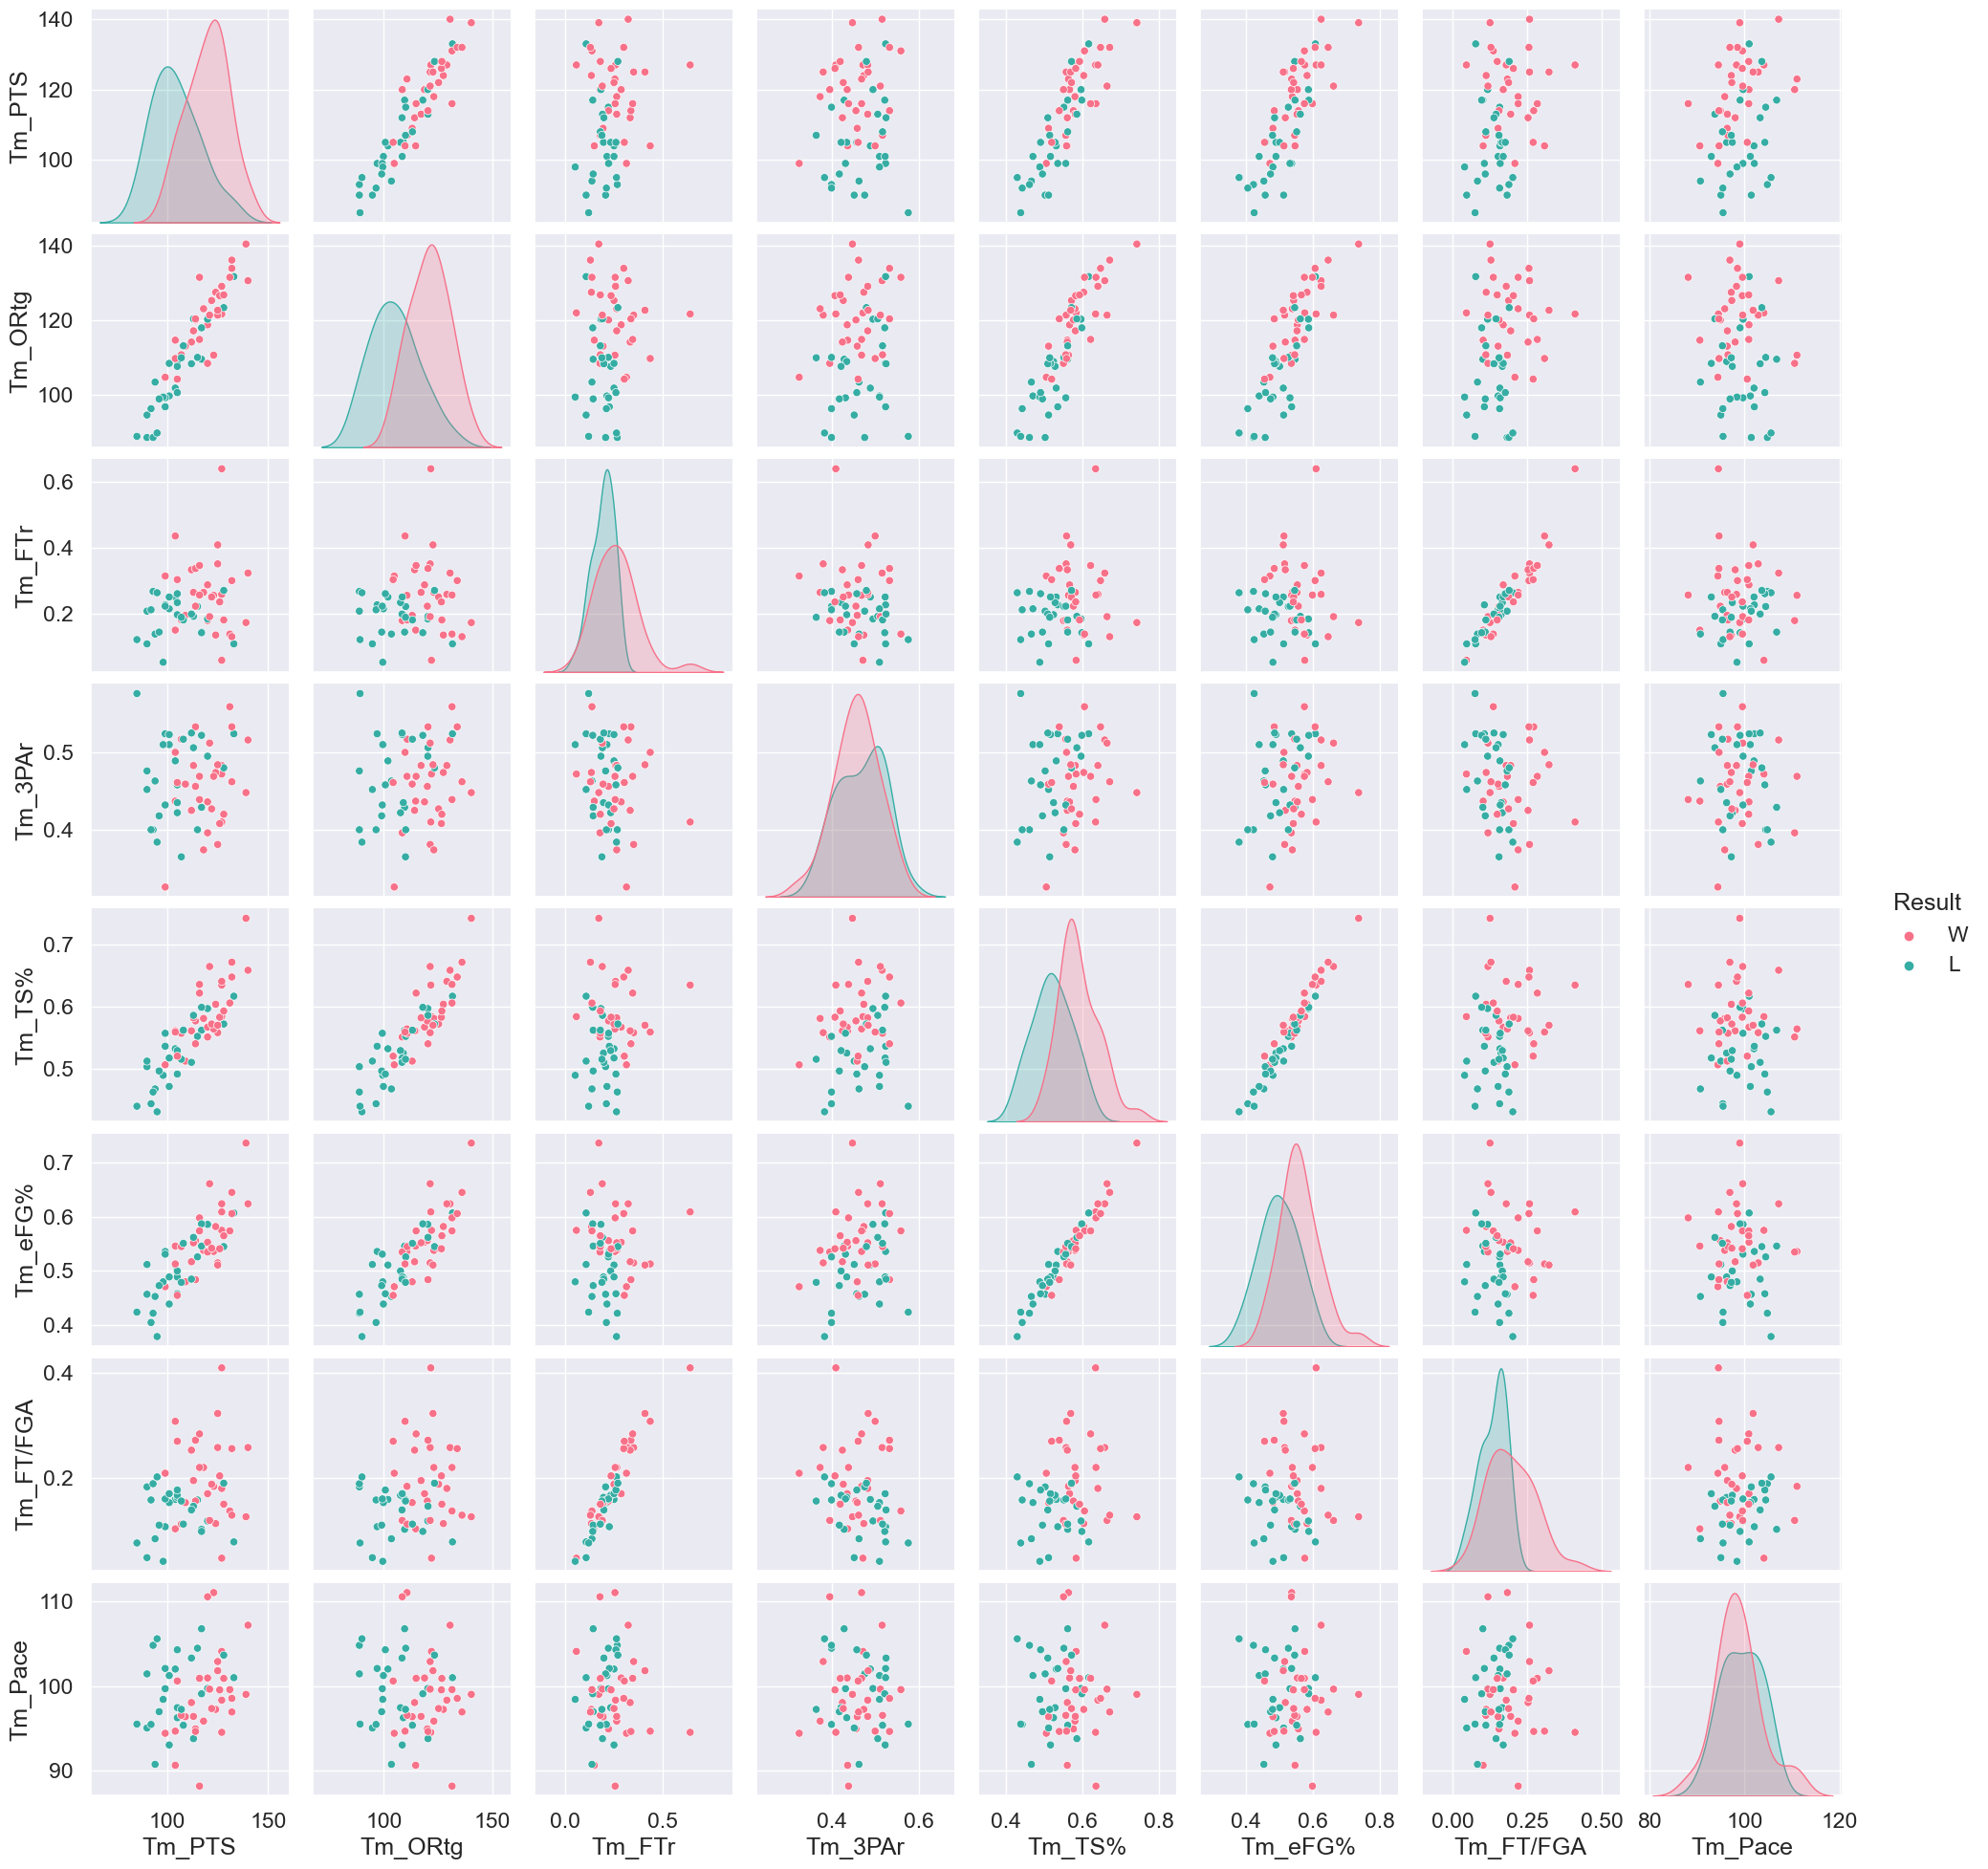

In [52]:
sns.pairplot(X_adv_sh, hue="Result", diag_kind='kde', kind='scatter', palette='husl')
plt.show()

In [59]:
adv_off= ['Tm_PTS', 'Result', 'Tm_ORB%','Tm_AST%', 'Opp_DRB', 'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%']


In [60]:
X_adv_off= df_team[adv_off]


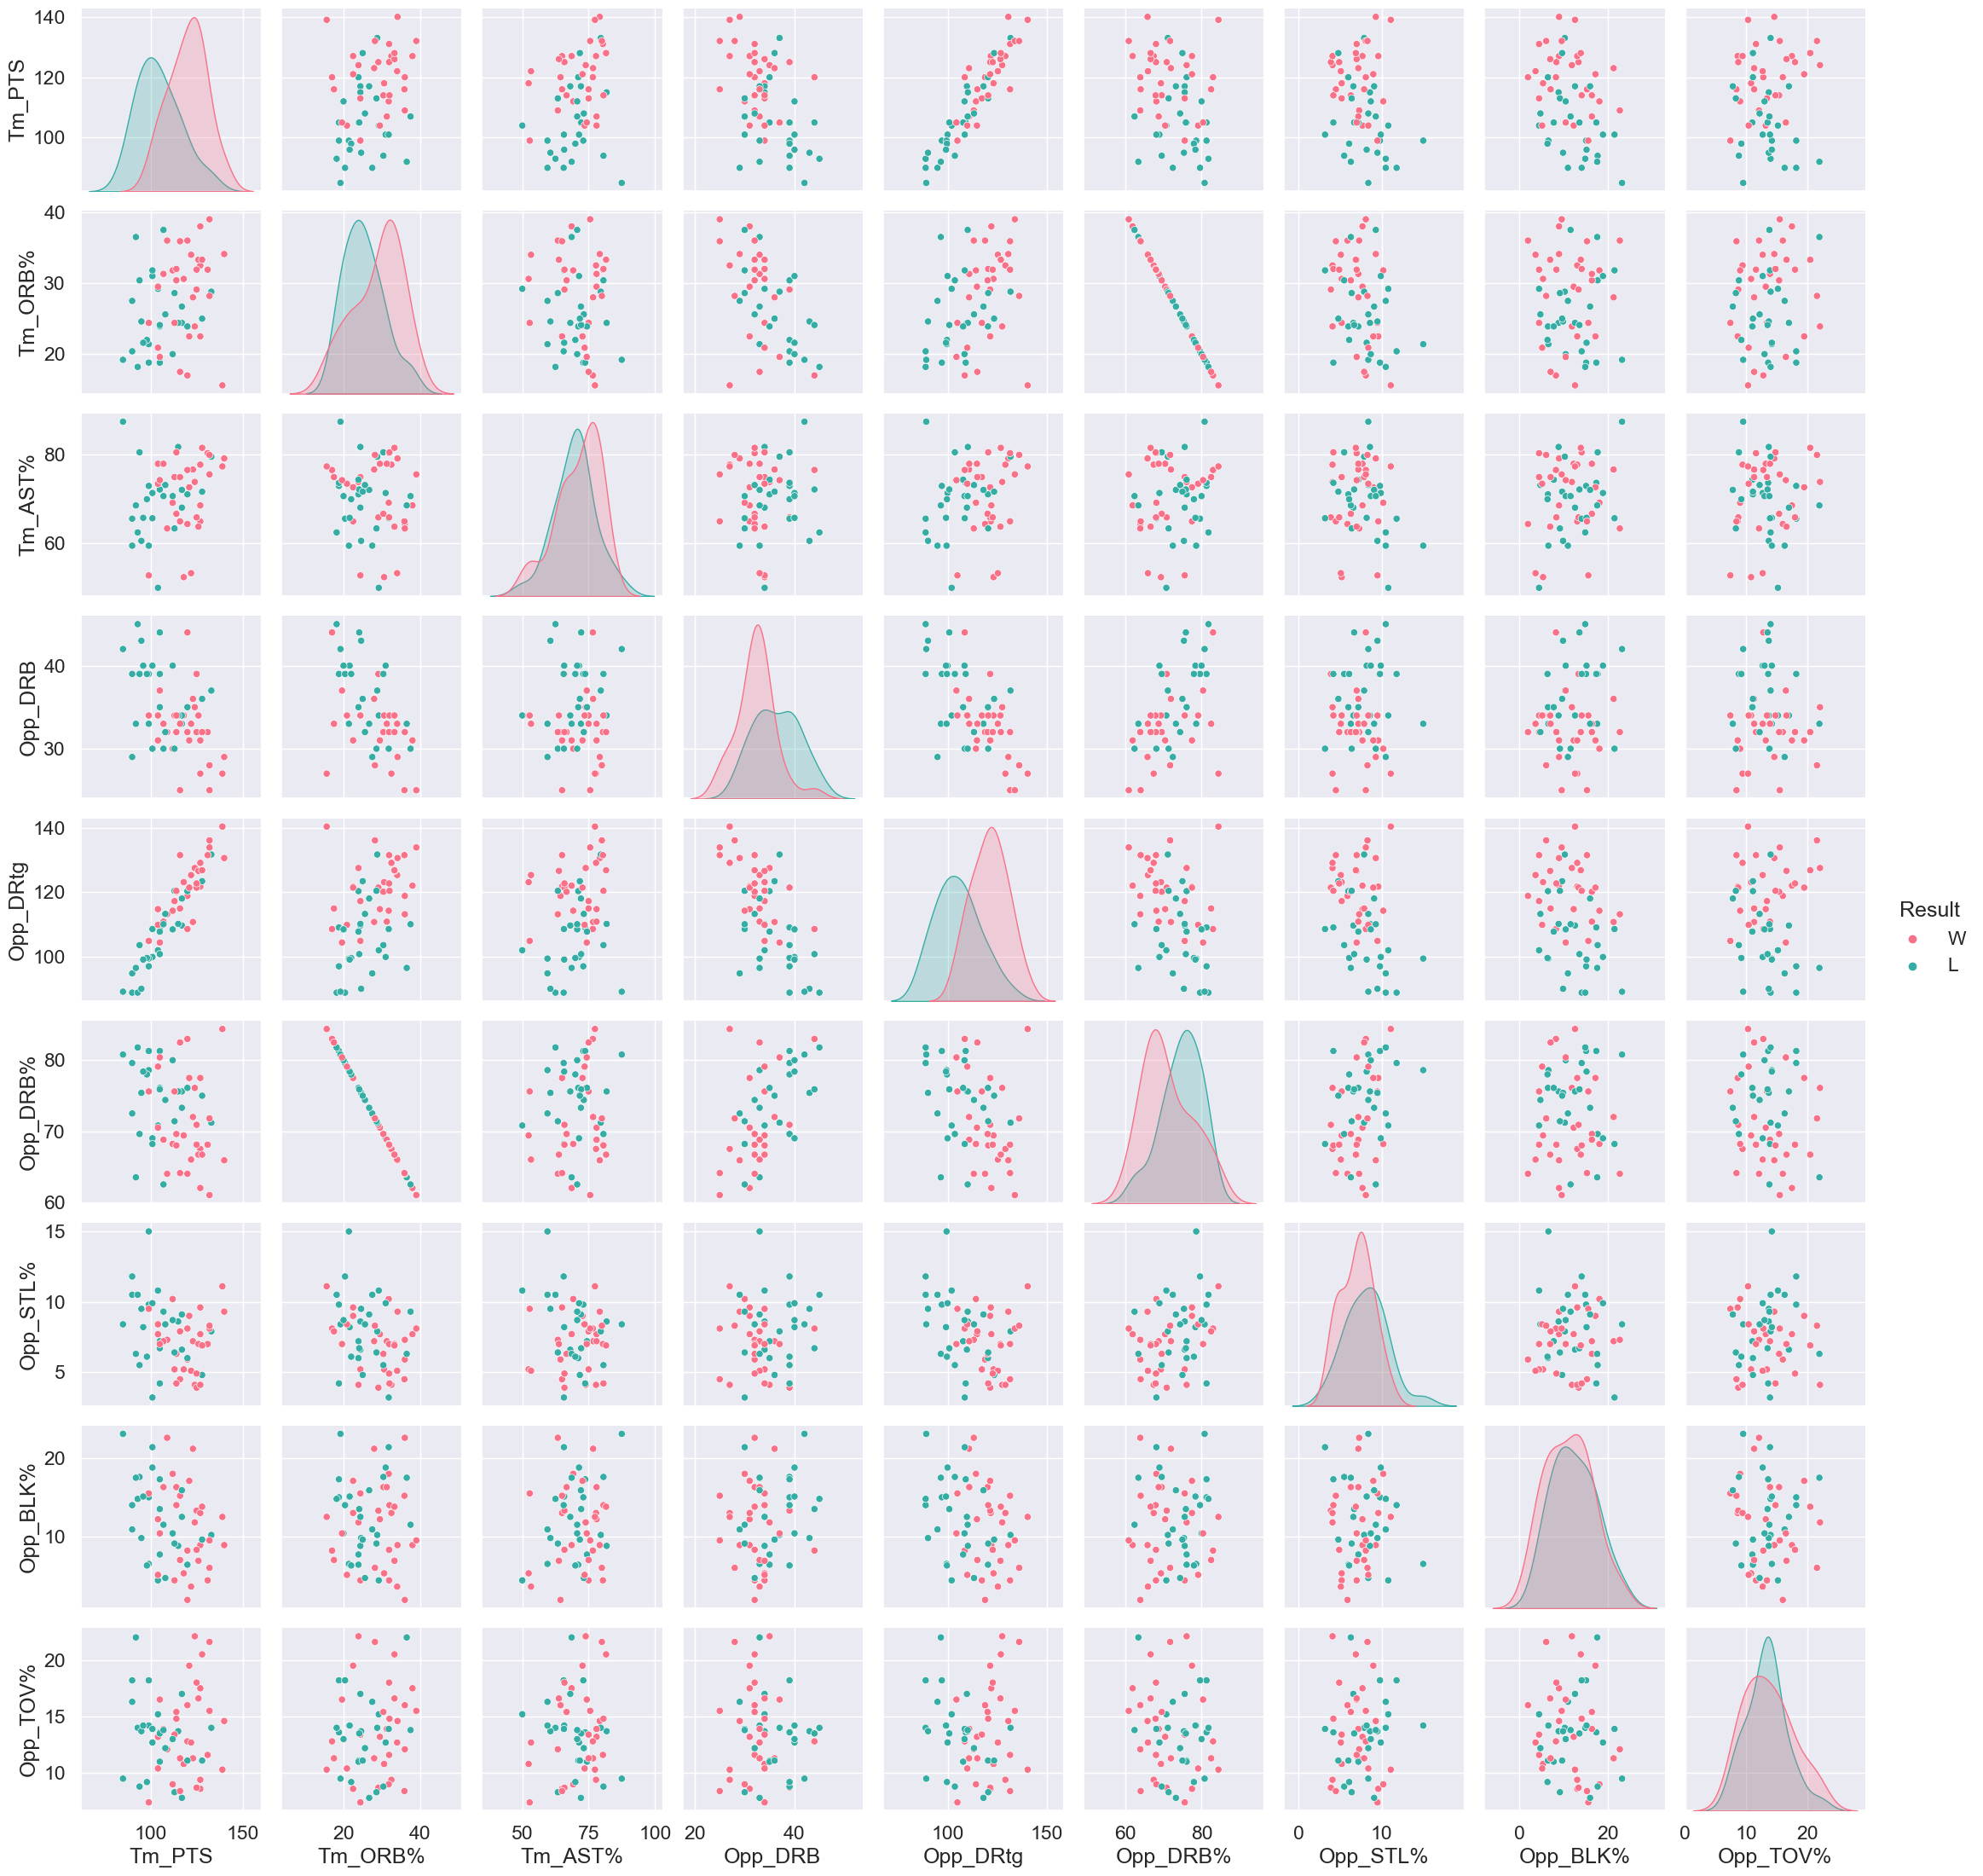

In [61]:
sns.pairplot(X_adv_off, hue="Result", diag_kind='kde', kind='scatter', palette='husl')
plt.show()